In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
sns.set_theme(style="whitegrid")
rng = np.random.default_rng(2024)
N = 395   

In [5]:
# ----------------------------------------------------------------------------
# BUILD student_stress.csv  (with realistic relationships so inferences hold)
# ----------------------------------------------------------------------------
sex = rng.choice(["F", "M"], N, p=[0.53, 0.47])
age = np.clip(rng.normal(16.7, 1.3, N).round().astype(int), 15, 22)
famsize = rng.choice(["GT3", "LE3"], N, p=[0.71, 0.29])
Pstatus = rng.choice(["T", "A"], N, p=[0.9, 0.1])
Medu = rng.choice([0, 1, 2, 3, 4], N, p=[0.03, 0.15, 0.26, 0.25, 0.31])
Fedu = rng.choice([0, 1, 2, 3, 4], N, p=[0.05, 0.18, 0.29, 0.25, 0.23])
jobs = ["teacher", "health", "services", "at_home", "other"]
Mjob = rng.choice(jobs, N, p=[0.14, 0.09, 0.23, 0.15, 0.39])
Fjob = rng.choice(jobs, N, p=[0.07, 0.05, 0.28, 0.05, 0.55])
guardian = rng.choice(["mother", "father", "other"], N, p=[0.69, 0.23, 0.08])
studytime = rng.choice([1, 2, 3, 4], N, p=[0.27, 0.50, 0.16, 0.07])
schoolsup = rng.choice(["yes", "no"], N, p=[0.13, 0.87])
famsup = rng.choice(["yes", "no"], N, p=[0.61, 0.39])
paid = rng.choice(["yes", "no"], N, p=[0.46, 0.54])
activities = rng.choice(["yes", "no"], N, p=[0.51, 0.49])
internet = rng.choice(["yes", "no"], N, p=[0.83, 0.17])
romantic = rng.choice(["yes", "no"], N, p=[0.33, 0.67])
famrel = np.clip(rng.normal(3.9, 0.9, N).round().astype(int), 1, 5)
freetime = np.clip(rng.normal(3.2, 1.0, N).round().astype(int), 1, 5)
goout = np.clip(rng.normal(3.1, 1.1, N).round().astype(int), 1, 5)
health = np.clip(rng.normal(3.5, 1.4, N).round().astype(int), 1, 5)
absences = np.clip(rng.gamma(2.0, 3.0, N).round().astype(int), 0, 93)


In [6]:
# Grades: studytime lifts G1; G2,G3 drift upward from the previous grade
G1 = np.clip(rng.normal(8 + studytime * 1.2, 2.6, N), 0, 20).round().astype(int)
G2 = np.clip(G1 + rng.normal(0.4, 1.6, N), 0, 20).round().astype(int)
G3 = np.clip(G2 + rng.normal(0.4, 1.6, N), 0, 20).round().astype(int)

# Stress: more likely with low grades, high goout, low famrel, low freetime, many absences
avg_g = (G1 + G2 + G3) / 3
stress_score = (-(avg_g - 11) * 0.18 + (goout - 3) * 0.25 - (famrel - 4) * 0.22
                - (freetime - 3) * 0.12 + (absences - 6) * 0.03
                + rng.normal(0, 0.7, N))
p_stress = 1 / (1 + np.exp(-stress_score))          # logistic -> probability
Stress = (rng.random(N) < p_stress).astype(int)

df = pd.DataFrame({
    "sex": sex, "age": age, "famsize": famsize, "Pstatus": Pstatus,
    "Medu": Medu, "Fedu": Fedu, "Mjob": Mjob, "Fjob": Fjob, "guardian": guardian,
    "studytime": studytime, "schoolsup": schoolsup, "famsup": famsup, "paid": paid,
    "activities": activities, "internet": internet, "romantic": romantic,
    "famrel": famrel, "freetime": freetime, "goout": goout, "health": health,
    "absences": absences, "G1": G1, "G2": G2, "G3": G3, "Stress": Stress,
})
OUT = "/mnt/user-data/outputs"
sns.set_theme(style="whitegrid")
rng = np.random.default_rng(2024)
N = 395   
print("student_stress.csv built:", df.shape)


student_stress.csv built: (395, 25)


In [8]:
# ============================================================================
print("\n" + "=" * 70)
print("QUESTION 4a  -  STUDENT STRESS DATASET")
print("=" * 70)
df = pd.read_csv("student_stress.csv")

# 4a.1  % of stressed students
pct_stressed = df["Stress"].mean() * 100        # mean of 0/1 = proportion stressed
print("\n[1] % stressed students:", round(pct_stressed, 2), "%")


QUESTION 4a  -  STUDENT STRESS DATASET

[1] % stressed students: 47.85 %


In [9]:
# 4a.2  average age of female students
avg_age_f = df[df["sex"] == "F"]["age"].mean()
print("[2] Average age of female students:", round(avg_age_f, 2))


[2] Average age of female students: 16.66


In [10]:
# 4a.3  add avg_grade column
df["avg_grade"] = (df["G1"] + df["G2"] + df["G3"]) / 3
print("[3] avg_grade column added. Sample:")
print(df[["G1", "G2", "G3", "avg_grade"]].head(5).to_string(index=False))


[3] avg_grade column added. Sample:
 G1  G2  G3  avg_grade
 12  13  10  11.666667
 11  12  10  11.000000
 12  13  16  13.666667
 13  16  17  15.333333
  7  10  11   9.333333


In [11]:
# 4a.4  correlation between studytime and avg_grade
corr = df["studytime"].corr(df["avg_grade"])
print("\n[4] Correlation studytime vs avg_grade:", round(corr, 3))


[4] Correlation studytime vs avg_grade: 0.371


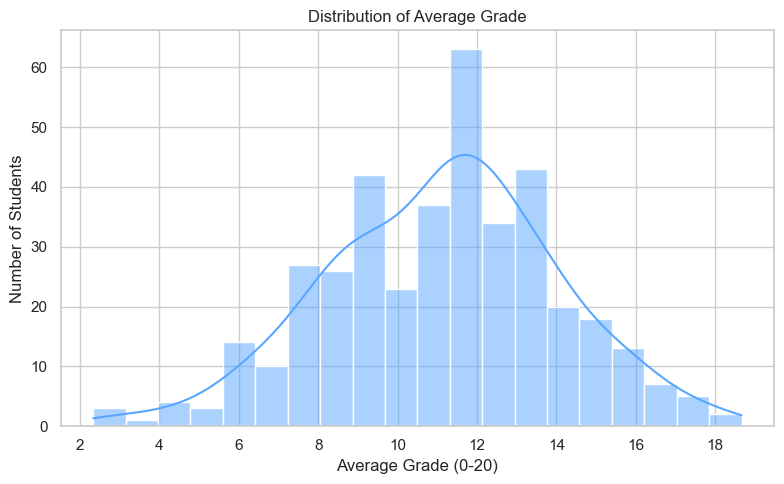

In [15]:
# 4a.5  distribution of avg_grade (histogram)
plt.figure(figsize=(8, 5))

sns.histplot(
    df["avg_grade"],
    bins=20,
    kde=True,
    color="#58a6ff"
)

plt.title("Distribution of Average Grade")
plt.xlabel("Average Grade (0-20)")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()   # Show first


In [16]:

# ============================================================================
print("\n" + "=" * 70)
print("QUESTION 4b  -  FAMILY ROLE IN STRESS")
print("=" * 70)

# 4b.1  crosstab: family relation quality vs stress
ct = pd.crosstab(df["famrel"], df["Stress"])
print("\n[1] Crosstab famrel vs Stress (0=not stressed, 1=stressed):")
print(ct.to_string())


QUESTION 4b  -  FAMILY ROLE IN STRESS

[1] Crosstab famrel vs Stress (0=not stressed, 1=stressed):
Stress   0   1
famrel        
1        2   1
2       11  13
3       48  54
4       86  81
5       59  40


In [17]:
# 4b.2  pivot table: stressed count by famsize and famsup
pv = pd.pivot_table(df, index="famsize", columns="famsup",
                    values="Stress", aggfunc="sum")          # sum of 1s = stressed count
print("\n[2] Pivot - stressed student COUNT by famsize x famsup:")
print(pv.to_string())



[2] Pivot - stressed student COUNT by famsize x famsup:
famsup   no  yes
famsize         
GT3      51   85
LE3      19   34


In [18]:
# 4b.3  min & max avg grade where a parent has higher education (Medu==4 or Fedu==4)
higher = df[(df["Medu"] == 4) | (df["Fedu"] == 4)]
print("\n[3] Higher-education-parent students:", len(higher))
print("    min avg_grade:", round(higher["avg_grade"].min(), 2),
      "| max avg_grade:", round(higher["avg_grade"].max(), 2))


[3] Higher-education-parent students: 173
    min avg_grade: 2.33 | max avg_grade: 18.33


In [19]:
# 4b.4  avg freetime in GT3 families; stressed students below that average
gt3 = df[df["famsize"] == "GT3"]
avg_ft = gt3["freetime"].mean()
below = gt3[(gt3["freetime"] < avg_ft) & (gt3["Stress"] == 1)]
print("\n[4] Avg freetime (GT3 families):", round(avg_ft, 3))
print("    GT3 students with freetime < avg AND stressed:", len(below))


[4] Avg freetime (GT3 families): 3.153
    GT3 students with freetime < avg AND stressed: 85



[5] working_mother counts:
yes    336
no      59


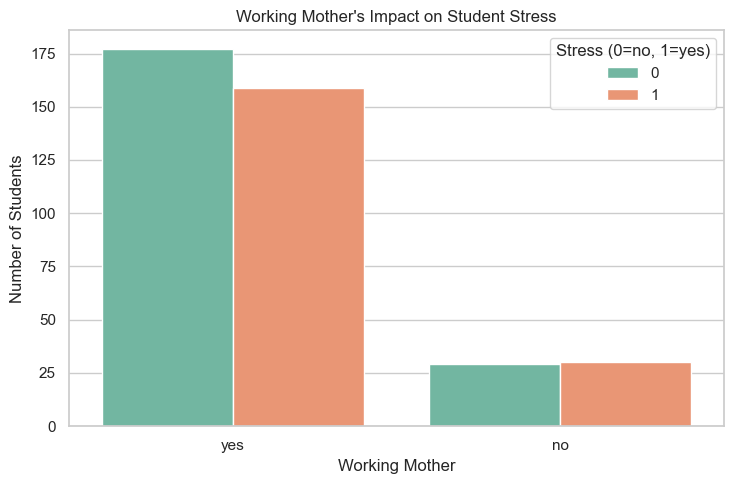

    stress count by working_mother:
Stress            0    1
working_mother          
no               29   30
yes             177  159


In [21]:
# 4b.5  working_mother column + plot of impact on stress count
df["working_mother"] = df["Mjob"].apply(
    lambda j: "no" if j == "at_home" else "yes"
)

print("\n[5] working_mother counts:")
print(df["working_mother"].value_counts().to_string())

plt.figure(figsize=(7.5, 5))

sns.countplot(
    data=df,
    x="working_mother",
    hue="Stress",
    palette="Set2"
)

plt.title("Working Mother's Impact on Student Stress")
plt.xlabel("Working Mother")
plt.ylabel("Number of Students")
plt.legend(title="Stress (0=no, 1=yes)")

plt.tight_layout()
plt.show()      # Display graph

print("    stress count by working_mother:")
print(pd.crosstab(df["working_mother"], df["Stress"]).to_string())


QUESTION 4c  -  MIXED ANALYSIS & PLOTS


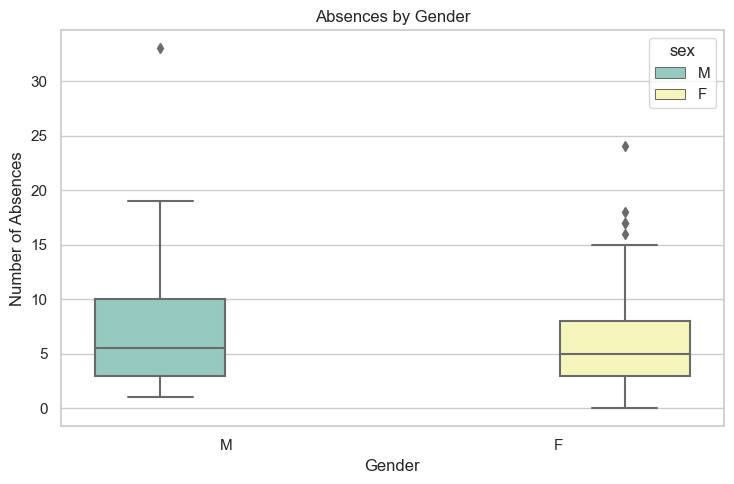


[1] Median absences by gender:
sex
F    5.0
M    5.5


In [24]:
# ============================================================================
print("\n" + "=" * 70)
print("QUESTION 4c  -  MIXED ANALYSIS & PLOTS")
print("=" * 70)

# 4c.1  boxplot of absences vs gender
plt.figure(figsize=(7.5, 5))

sns.boxplot(
    data=df,
    x="sex",
    y="absences",
    hue="sex",
    palette="Set3",
)

plt.title("Absences by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Absences")

plt.tight_layout()
plt.show()

print("\n[1] Median absences by gender:")
print(df.groupby("sex")["absences"].median().to_string())

In [ ]:
# 4c.2  pie chart of father's occupations
fjob_counts = df["Fjob"].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(fjob_counts, labels=fjob_counts.index, autopct="%1.1f%%", startangle=90,
        colors=sns.color_palette("pastel"))
plt.title("Father's Occupation Distribution")
plt.tight_layout(); plt.savefig(f"{OUT}/4c2_fjob_pie.png", dpi=90); plt.close()
print("\n[2] Father occupation counts:")
print(fjob_counts.to_string())


In [ ]:

# 4c.3  students who improved across all three evaluations (G1 < G2 < G3)
progressive = df[(df["G1"] < df["G2"]) & (df["G2"] < df["G3"])]
print("\n[3] Students performing progressively (G1<G2<G3):", len(progressive))

In [ ]:
# 4c.4  romantic students who are progressive, by gender
rom_prog = progressive[progressive["romantic"] == "yes"]
print("\n[4] Romantic AND progressive students:", len(rom_prog))
print("    gender-wise distribution:")
print(rom_prog.groupby("sex").size().reindex(["F", "M"], fill_value=0).to_string())

print("\nPlots saved: 4a5_avggrade.png, 4b5_workingmother.png, "
      "4c1_absences.png, 4c2_fjob_pie.png")
print("Done.")
